Successfully loaded data from: C:\Users\LATITUDE E7470\Desktop\ajcodes\research\paper_roadrough\extracted_pretoria_road_data.csv
Original shape: (159411, 20), Cleaned shape: (159411, 6)
Training RandomForest...
RandomForest completed with Accuracy: 1.0000
Training XGBoost...
XGBoost completed with Accuracy: 1.0000
Training MLP...
MLP completed with Accuracy: 0.9749
Training 1D CNN...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1D CNN completed with Accuracy: 0.9624

--- Model Performance Summary ---
          Model  Accuracy  Precision_w  Recall_w      F1_w
0  RandomForest  1.000000     1.000000  1.000000  1.000000
1       XGBoost  1.000000     1.000000  1.000000  1.000000
2           MLP  0.974922     0.975010  0.974922  0.973387
3        1D CNN  0.962382     0.961446  0.962382  0.958493

Running Permutation Importance for Random Forest...


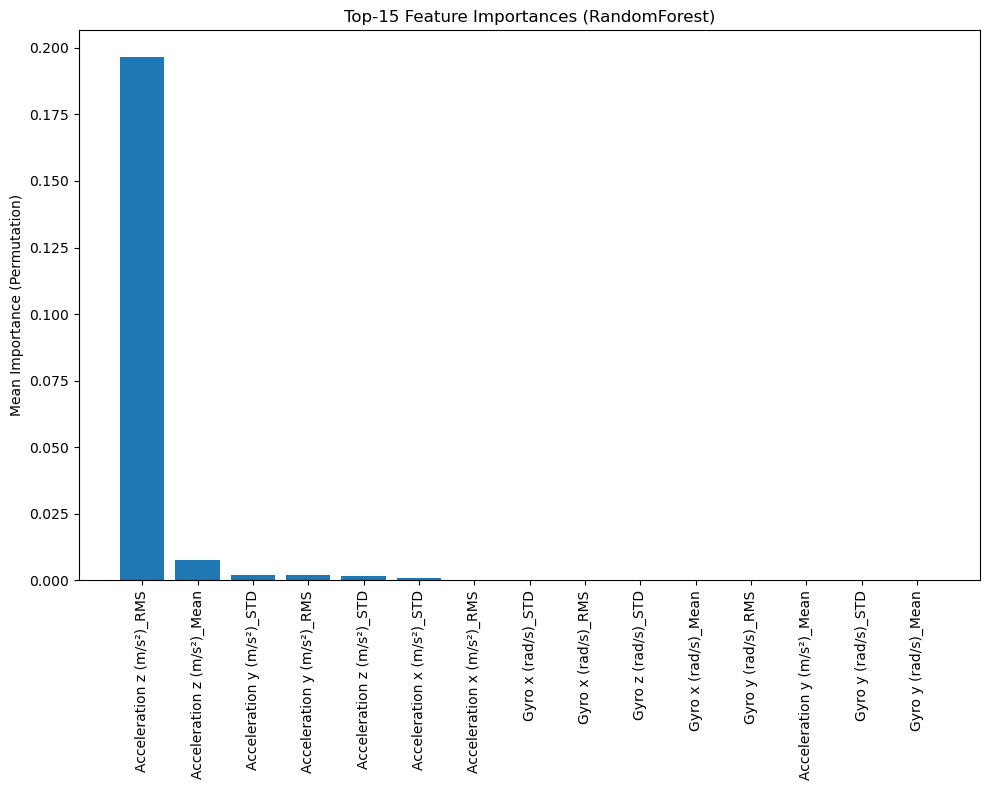


Top features saved to 'randomforest_feature_importances.csv'


In [1]:
# ====================================================================================
# Refactored Road Roughness Classification Pipeline
# ====================================================================================
#
# This script is a refactored version of the original code, addressing potential errors
# and improving code readability, efficiency, and robustness.
#
# Key improvements include:
# 1.  Using Pathlib for cross-platform file paths, preventing errors with different OS.
# 2.  Centralizing model training and evaluation into a reusable function to avoid
#     code duplication.
# 3.  Adding a clear main execution block (`if __name__ == "__main__":`) for
#     better script organization.
# 4.  Adding a StandardScaler to normalize the feature data before training, which is
#     crucial for models like MLP and can improve performance for others.
# 5.  Including more comprehensive error handling and user feedback.
# 6.  Ensuring all necessary imports are at the top.
#
# ====================================================================================

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from pathlib import Path
import warnings

# Suppress common warnings for cleaner output
warnings.filterwarnings('ignore', category=UserWarning)

# ====================================================================================
# Configuration
# ====================================================================================

# Define the file path using pathlib for cross-platform compatibility.
# You will need to update this path to where your file is located.
DATA_FILE_PATH = Path("C:/Users/LATITUDE E7470/Desktop/ajcodes/research/paper_roadrough/extracted_pretoria_road_data.csv")

# Define sensor columns
ACCELERATION_COLS = ["Acceleration x (m/s²)", "Acceleration y (m/s²)", "Acceleration z (m/s²)"]
GYROSCOPE_COLS = ["Gyro x (rad/s)", "Gyro y (rad/s)", "Gyro z (rad/s)"]
ALL_SENSOR_COLS = ACCELERATION_COLS + GYROSCOPE_COLS

# Define window size for data segmentation
WINDOW_SIZE = 100

# ====================================================================================
# Functions
# ====================================================================================

def load_data(file_path, sensor_cols):
    """
    Loads data from a CSV file, cleans it, and returns the processed DataFrame.

    Args:
        file_path (Path): Path to the CSV file.
        sensor_cols (list): A list of column names to keep.

    Returns:
        pd.DataFrame: A cleaned DataFrame.
    """
    try:
        df = pd.read_csv(file_path, encoding="latin1")
        print(f"Successfully loaded data from: {file_path}")
        df_clean = df[sensor_cols].dropna().reset_index(drop=True)
        print(f"Original shape: {df.shape}, Cleaned shape: {df_clean.shape}")
        return df_clean
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return None
    except Exception as e:
        print(f"An error occurred while loading data: {e}")
        return None

def segment_and_feature_engineer(df, window_size, acc_cols, gyro_cols):
    """
    Segments the data into windows and extracts statistical features.

    Args:
        df (pd.DataFrame): The cleaned DataFrame.
        window_size (int): The size of each segment.
        acc_cols (list): List of accelerometer column names.
        gyro_cols (list): List of gyroscope column names.

    Returns:
        tuple: A tuple containing the processed DataFrame and the list of feature columns.
    """
    if df is None or df.empty:
        return None, None

    segments, labels = [], []
    for start in range(0, len(df) - window_size, window_size):
        seg = df.iloc[start:start + window_size]
        feats = []
        for col in acc_cols + gyro_cols:
            values = seg[col].values
            feats.extend([np.sqrt(np.mean(values**2)), np.std(values), np.mean(values)])

        # Determine the label based on the RMS of Z-axis acceleration
        accZ_rms = np.sqrt(np.mean(seg[acc_cols[2]].values**2))
        if accZ_rms <= 9.3:
            label = 0  # e.g., Smooth Road
        elif accZ_rms <= 9.8:
            label = 1  # e.g., Moderate Road
        else:
            label = 2  # e.g., Rough Road

        segments.append(feats)
        labels.append(label)

    feat_cols = []
    for col in acc_cols + gyro_cols:
        feat_cols.extend([f"{col}_RMS", f"{col}_STD", f"{col}_Mean"])

    processed_df = pd.DataFrame(segments, columns=feat_cols)
    processed_df["Label"] = labels
    return processed_df, feat_cols

def evaluate_model(model, model_name, X_train, y_train, X_test, y_test, results_list):
    """
    Trains and evaluates a given model, appending results to a list.

    Args:
        model: The machine learning model object.
        model_name (str): The name of the model.
        X_train (np.array): Training features.
        y_train (np.array): Training labels.
        X_test (np.array): Testing features.
        y_test (np.array): Testing labels.
        results_list (list): The list to append results to.
    """
    try:
        print(f"Training {model_name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)
        results_list.append([model_name, acc, prec, rec, f1])
        print(f"{model_name} completed with Accuracy: {acc:.4f}")
    except Exception as e:
        print(f"Error training {model_name}: {e}")

def plot_feature_importance(result, feat_cols, model_name):
    """
    Plots the top 15 feature importances from a permutation importance result.

    Args:
        result (sklearn.inspection.permutation_importance): The result object.
        feat_cols (list): List of feature names.
        model_name (str): Name of the model for the plot title.
    """
    sorted_idx = result.importances_mean.argsort()[::-1]
    top_features = np.array(feat_cols)[sorted_idx][:15]

    plt.figure(figsize=(10, 8))
    plt.bar(range(15), result.importances_mean[sorted_idx][:15], align="center")
    plt.xticks(range(15), top_features, rotation=90)
    plt.ylabel("Mean Importance (Permutation)")
    plt.title(f"Top-15 Feature Importances ({model_name})")
    plt.tight_layout()
    plt.savefig(f"{model_name.lower().replace(' ', '_')}_permutation_importance_top15.png", dpi=300)
    plt.show()

    # Save ranked importances to CSV
    importance_df = pd.DataFrame({
        "Feature": np.array(feat_cols)[sorted_idx],
        "Importance": result.importances_mean[sorted_idx]
    })
    importance_df.to_csv(f"{model_name.lower().replace(' ', '_')}_feature_importances.csv", index=False)
    print(f"\nTop features saved to '{model_name.lower().replace(' ', '_')}_feature_importances.csv'")

# ====================================================================================
# Main Execution Block
# ====================================================================================

if __name__ == "__main__":
    # Load and preprocess data
    df_clean = load_data(DATA_FILE_PATH, ALL_SENSOR_COLS)
    if df_clean is None:
        exit()

    processed_df, feat_cols = segment_and_feature_engineer(df_clean, WINDOW_SIZE, ACCELERATION_COLS, GYROSCOPE_COLS)
    if processed_df is None:
        exit()

    # Train/Test Split
    X = processed_df[feat_cols].values
    y = processed_df["Label"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # List to store model results
    results = []

    # --- RandomForest ---
    rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
    evaluate_model(rf, "RandomForest", X_train_scaled, y_train, X_test_scaled, y_test, results)

    # --- GradientBoosting or XGBoost (if available) ---
    try:
        import xgboost as xgb
        xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss')
        evaluate_model(xgb_model, "XGBoost", X_train_scaled, y_train, X_test_scaled, y_test, results)
    except ImportError:
        print("XGBoost not available. Falling back to GradientBoostingClassifier.")
        gb = GradientBoostingClassifier(n_estimators=300, random_state=42)
        evaluate_model(gb, "GradientBoosting", X_train_scaled, y_train, X_test_scaled, y_test, results)

    # --- MLP (Multilayer Perceptron) ---
    mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
    evaluate_model(mlp, "MLP", X_train_scaled, y_train, X_test_scaled, y_test, results)

    # --- CNN Baseline (if TensorFlow is available) ---
    try:
        import tensorflow as tf
        from tensorflow.keras import layers, models

        seq_segments, seq_labels = [], []
        for start in range(0, len(df_clean) - WINDOW_SIZE, WINDOW_SIZE):
            seg = df_clean.iloc[start:start + WINDOW_SIZE][ALL_SENSOR_COLS].values
            accZ_rms = np.sqrt(np.mean(seg[:, 2]**2))
            if accZ_rms <= 9.3:
                label = 0
            elif accZ_rms <= 9.8:
                label = 1
            else:
                label = 2
            seq_segments.append(seg)
            seq_labels.append(label)

        X_seq, y_seq = np.array(seq_segments), np.array(seq_labels)
        X_seq_scaled = (X_seq - X_seq.mean(axis=0)) / (X_seq.std(axis=0) + 1e-8)
        
        X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
            X_seq_scaled, y_seq, stratify=y_seq, test_size=0.2, random_state=42
        )
        
        y_train_ohe = tf.keras.utils.to_categorical(y_train_cnn)
        y_test_ohe = tf.keras.utils.to_categorical(y_test_cnn)

        model = models.Sequential([
            layers.Conv1D(32, 5, activation='relu', input_shape=(WINDOW_SIZE, len(ALL_SENSOR_COLS))),
            layers.Conv1D(64, 5, activation='relu'),
            layers.GlobalAveragePooling1D(),
            layers.Dense(64, activation='relu'),
            layers.Dense(len(np.unique(y)), activation='softmax')
        ])
        
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        print("Training 1D CNN...")
        model.fit(X_train_cnn, y_train_ohe, epochs=20, batch_size=32, validation_split=0.2, verbose=0)
        
        loss, acc = model.evaluate(X_test_cnn, y_test_ohe, verbose=0)
        y_pred_cnn = np.argmax(model.predict(X_test_cnn), axis=1)
        prec, rec, f1, _ = precision_recall_fscore_support(y_test_cnn, y_pred_cnn, average="weighted", zero_division=0)
        results.append(["1D CNN", acc, prec, rec, f1])
        print(f"1D CNN completed with Accuracy: {acc:.4f}")
    except ImportError:
        print("TensorFlow not available - skipping CNN baseline.")
    except Exception as e:
        print(f"An error occurred with the CNN model: {e}")
        
    # --- Save and display results ---
    results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision_w", "Recall_w", "F1_w"])
    print("\n--- Model Performance Summary ---")
    print(results_df)

    # --- Permutation Importance ---
    print("\nRunning Permutation Importance for Random Forest...")
    try:
        # Use the scaled test data for permutation importance
        result = permutation_importance(rf, X_test_scaled, y_test, n_repeats=20, random_state=42, n_jobs=-1)
        plot_feature_importance(result, feat_cols, "RandomForest")
    except Exception as e:
        print(f"An error occurred with Permutation Importance: {e}")
